## Mapping CU **Boulder** (East Campus) OpenStreetMap and Python

![https://seec.colorado.edu/assets/seec_landscape.jpeg](https://seec.colorado.edu/assets/seec_landscape.jpeg)


In this notebook, we will use **OpenStreetMap (OSM)** data and Python to create a map of **East Campus at the University of Colorado Boulder**.

OpenStreetMap is a global, community-built map database that includes information about roads, buildings, water features, boundaries, parks, and many other types of geographic features. Using Python, we can search for a place, download spatial data from OSM, and create maps that help us better understand the built and natural environment around that location.

During the demo, we will walk through a workflow that shows how to:

- Search for a place using OSM
- Download geographic features such as buildings, roads, water, and boundaries
- Store those features as GeoDataFrames
- Create a map using Python
- Customize the map to make different features easier to see

We will begin by mapping **CU Boulder’s East Campus** as an example. After the demo, you will have time to repeat the workflow for a campus, neighborhood, town, park, or other place of your choosing.

By the end of this activity, you should have a basic understanding of how Python can be used to access open geographic data and create maps for exploring real places.

In [1]:
# Uncomment this cell if running notebook in Google Colab
!pip install osmnx hvplot geoviews

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 574.7/574.7 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 27.5 MB/s eta 0:00:00


## Import Python Libraries

Before we begin mapping, we need to import the Python libraries that will help us download, organize, and visualize spatial data.

This notebook uses several different libraries:

- **osmnx** is used to search for and download data from OpenStreetMap.
- **geopandas** is used to work with spatial data in Python.
- **matplotlib** is used to create static plots and maps.
- **hvplot** is used to create interactive maps.

The code below imports the libraries we will use throughout the notebook.

In [2]:
# Import python libraries
import osmnx as osm
import geopandas as gpd
import matplotlib.pyplot as plt
import hvplot.pandas
import geoviews
import holoviews as hv

## Search for a Place with `geocode_to_gdf()`

Next, we will search for **University of Colorado Boulder** using the `geocode_to_gdf()` function from `osmnx`.

This function sends a place name to OpenStreetMap and returns the result as a **GeoDataFrame**. A GeoDataFrame is similar to a regular pandas DataFrame, but it includes a special `geometry` column that stores spatial information such as points, lines, or polygons.

In this example, we are asking OSM to find the boundary or location associated with **University of Colorado Boulder**.

The output will show the OpenStreetMap search result in table form. Important columns may include the place name, type of feature, OpenStreetMap ID, bounding box information, and geometry.

We will use this GeoDataFrame as the starting point for mapping CU Boulder.

In [3]:
# Look for CU Boulder using geocode_to_gdf
cu_boulder_gdf = osm.geocode_to_gdf("University of Colorado Boulder")
cu_boulder_gdf

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((-105.2766 40.01029, -105.2766 40.010...",-105.276605,40.000279,-105.258821,40.013632,330982900,way,46226108,40.007006,-105.266442,boundary,administrative,25,0.583709,administrative,University of Colorado Boulder (Main Campus),"University of Colorado Boulder (Main Campus), ..."


## Plot the CU Boulder Boundary

Now that we have a GeoDataFrame for **University of Colorado Boulder**, we can create a quick plot of the geometry.

This first map is a simple, static plot. It gives us a quick way to check whether the data we downloaded from OpenStreetMap looks reasonable.

At this stage, the map may look very simple. That is okay. The goal is to confirm that Python found a spatial feature for CU Boulder and that the geometry can be plotted.

Later, we will add more geographic features, such as buildings, roads, and water, to create a more detailed map.

<Axes: >

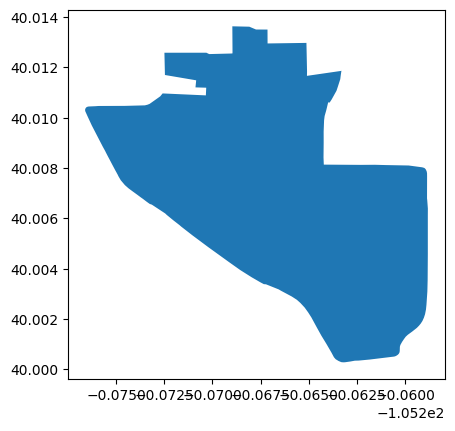

In [4]:
# Plot the boundary
cu_boulder_gdf.plot()

## Search for OSM Features Near an Address

There are multiple ways to search for data in OpenStreetMap. In the previous example, we used `geocode_to_gdf()` to search for a place boundary. Another approach is to search for **specific types of features** near a location.

In this example, we are using `features_from_address()` to search within **1,000 meters** of an address for features tagged as a university.

OSM data are organized using **tags**, which describe what a feature is. Tags are often written as key-value pairs. Here, we are searching for features where:

- the key is `amenity`
- the value is `university`

This means we are asking OpenStreetMap to return nearby features that are labeled as universities.

The `dist=1000` argument controls the search distance. In this case, Python will search for matching OSM features within 1,000 meters of the address.

The output is a GeoDataFrame containing the matching OSM features. This can be useful when you want to search for a category of features near a location rather than only searching for one named place.

In [ ]:
# Look for everything labeled 'University' within 1000m of an address
boulder_uni = osm.features_from_address(
    'Boulder, Colorado, USA',
    {'amenity': ['university']},
    dist=2000) # adjust dist= to find more buildings
boulder_uni

geometry  \
element id                                                             
way     46226108   POLYGON ((-105.27589 40.01047, -105.27597 40.0...   
        76453704   POLYGON ((-105.25317 40.01365, -105.25365 40.0...   
        203508769  POLYGON ((-105.24734 39.99889, -105.24733 39.9...   
        203508770  POLYGON ((-105.24815 40.01829, -105.24816 40.0...   
        391232001  POLYGON ((-105.26632 40.01452, -105.26631 40.0...   

                      amenity        boundary internet_access  \
element id                                                      
way     46226108   university  administrative            wlan   
        76453704   university  administrative             NaN   
        203508769  university  administrative             NaN   
        203508770  university  administrative             NaN   
        391232001  university             NaN             NaN   

                                                                name  \
element id                                                             
way     46226108        University of Colorado Boulder (Main Campus)   
        76453704        University of Colorado Boulder (East Campus)   
        203508769  University of Colorado Boulder (Williams Village)   
        203508770              University of Colorado Boulder (CINC)   
        391232001                                  Naropa University   

                                         operator  short_name  \
element id                                                      
way     46226108   University of Colorado Boulder  CU Boulder   
        76453704   University of Colorado Boulder         NaN   
        203508769  University of Colorado Boulder         NaN   
        203508770  University of Colorado Boulder         NaN   
        391232001               Naropa University         NaN   

                                     website  wikidata  \
element id                                               
way     46226108   https://www.colorado.edu/   Q736674   
        76453704                         NaN       NaN   
        203508769                        NaN       NaN   
        203508770                        NaN       NaN   
        391232001     https://www.naropa.edu  Q2975783   

                                           wikipedia  check_date   loc_name  \
element id                                                                    
way     46226108   en:University of Colorado Boulder         NaN        NaN   
        76453704                                 NaN  2024-05-06        NaN   
        203508769                                NaN         NaN  Will Vill   
        203508770                                NaN         NaN        NaN   
        391232001               en:Naropa University         NaN        NaN   

                    ele gnis:feature_id  
element id                               
way     46226108    NaN             NaN  
        76453704    NaN             NaN  
        203508769   NaN             NaN  
        203508770   NaN             NaN  
        391232001  1620          178660

## Find East Campus

Now that we have seen a couple of ways to query OpenStreetMap, we will focus on one specific area for the rest of the demonstration: **CU Boulder East Campus**.

Rather than running a new OSM search, we will use the results from the earlier `features_from_address()` query and select the row that represents East Campus.

In this step, we search within the existing `boulder_uni` GeoDataFrame for the East Campus feature and save the result as a new GeoDataFrame called `east_campus`.

We will use `east_campus` as the main boundary for the rest of the mapping workflow. Starting with a defined study area helps us find, clip, and plot other map layers, such as buildings, roads, water features, and other geographic data.

We also plot the East Campus boundary to check that we selected the correct feature before moving on.

In [ ]:
# Find University of Colorado (East Campus)
east_campus = boulder_uni[boulder_uni["name"]=="University of Colorado Boulder (East Campus)"]
east_campus

,,geometry,amenity,boundary,internet_access,name,operator,short_name,website,wikidata,wikipedia,check_date,loc_name,ele,gnis:feature_id
element,id,,,,,,,,,,,,,,
way,76453704,"POLYGON ((-105.25317 40.01365, -105.25365 40.0...",university,administrative,NaN,University of Colorado Boulder (East Campus),University of Colorado Boulder,NaN,NaN,NaN,NaN,2024-05-06,NaN,NaN,NaN


<Axes: >

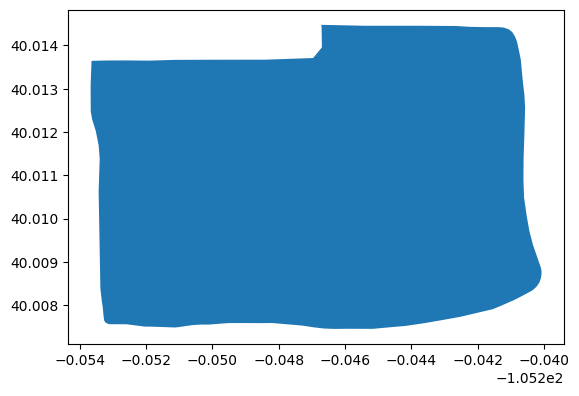

In [ ]:
# Plot the data
east_campus.plot()

## Extract the East Campus Polygon

The `east_campus` GeoDataFrame includes a `geometry` column that stores the spatial shape returned from OpenStreetMap.

In this step, we extract the first geometry from that GeoDataFrame and save it as a variable called `polygon`.

Because our OSM search returned the boundary of East Campus, this geometry should be a **polygon**. A polygon is a closed shape that represents an area, such as a campus boundary, park, lake, or neighborhood.

We will use this polygon to define our study area. Later, it can help us find or clip other OSM features so that our map focuses on East Campus rather than the surrounding area.

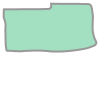

In [ ]:
# Extract ploygon from geometry
polygon = east_campus.geometry.iloc[0]
polygon

## Find Buildings Within the East Campus Boundary

Now that we have extracted the East Campus polygon, we can use it to search for features **inside that boundary**.

In this step, we use `features_from_polygon()` to find all OpenStreetMap features within the East Campus polygon that have a `building` tag.

The tag:

`{"building": True}`

means that we are asking OpenStreetMap to return any feature that is labeled as a building, regardless of the specific building type. This may include classrooms, labs, offices, residence buildings, garages, and other structures.

The result is stored as a GeoDataFrame called `buildings`. Each row represents a building feature returned from OSM, and the `geometry` column stores the shape of that building.

This layer will help us add more detail to our East Campus map.

In [ ]:
# Get buildings with the polygon using features_from_polygon()
buildings = osm.features_from_polygon(polygon,
                                      tags={"building": True})
buildings

geometry  \
element id                                                              
way     76437386    POLYGON ((-105.25234 40.01343, -105.25234 40.0...   
        76486597    POLYGON ((-105.25295 40.01228, -105.25273 40.0...   
        76486599    POLYGON ((-105.25326 40.0119, -105.25289 40.01...   
        76486601    POLYGON ((-105.25341 40.01342, -105.25262 40.0...   
        76486603    POLYGON ((-105.24908 40.01348, -105.24867 40.0...   
        76486607    POLYGON ((-105.25006 40.01298, -105.24955 40.0...   
        76486609    POLYGON ((-105.25343 40.01272, -105.25264 40.0...   
        99613171    POLYGON ((-105.24256 40.01035, -105.24245 40.0...   
        121868785   POLYGON ((-105.24658 40.00829, -105.24658 40.0...   
        121868888   POLYGON ((-105.24633 40.01166, -105.24609 40.0...   
        177434080   POLYGON ((-105.2527 40.01072, -105.2527 40.010...   
        177434810   POLYGON ((-105.24922 40.00902, -105.24922 40.0...   
        177435021   POLYGON ((-105.24695 40.00951, -105.24743 40.0...   
        199931436   POLYGON ((-105.24639 40.01434, -105.2464 40.01...   
        203538393   POLYGON ((-105.2532 40.01019, -105.2532 40.010...   
        203538394   POLYGON ((-105.25319 40.00885, -105.25319 40.0...   
        203538395   POLYGON ((-105.25207 40.00854, -105.25207 40.0...   
        203538396   POLYGON ((-105.2527 40.00954, -105.25271 40.00...   
        203538397   POLYGON ((-105.25256 40.0098, -105.25256 40.00...   
        203538398   POLYGON ((-105.25291 40.00984, -105.25291 40.0...   
        203538399   POLYGON ((-105.2531 40.00929, -105.25324 40.00...   
        203538400   POLYGON ((-105.25248 40.01009, -105.25248 40.0...   
        203538401   POLYGON ((-105.25263 40.00863, -105.25264 40.0...   
        203538403   POLYGON ((-105.25235 40.00817, -105.25235 40.0...   
        203538404   POLYGON ((-105.25324 40.00997, -105.25325 40.0...   
        203538405   POLYGON ((-105.25213 40.00976, -105.25213 40.0...   
        203538406   POLYGON ((-105.25319 40.00904, -105.25319 40.0...   
        203538407   POLYGON ((-105.25221 40.00891, -105.25221 40.0...   
        203538408   POLYGON ((-105.25268 40.00931, -105.25268 40.0...   
        203538983   POLYGON ((-105.25321 40.00829, -105.25308 40.0...   
        203538984   POLYGON ((-105.25321 40.00806, -105.25287 40.0...   
        203538985   POLYGON ((-105.25257 40.00828, -105.25271 40.0...   
        203538986   POLYGON ((-105.25179 40.00769, -105.25179 40.0...   
        203538987   POLYGON ((-105.25201 40.00937, -105.25164 40.0...   
        207270752   POLYGON ((-105.25093 40.01353, -105.25093 40.0...   
        207775084   POLYGON ((-105.24956 40.00974, -105.24956 40.0...   
        207775085   POLYGON ((-105.24955 40.00994, -105.24955 40.0...   
        264694038   POLYGON ((-105.24654 40.00888, -105.24654 40.0...   
        264694043   POLYGON ((-105.24841 40.00959, -105.24845 40.0...   
        264694045   POLYGON ((-105.25183 40.00946, -105.25178 40.0...   
        264694047   POLYGON ((-105.24905 40.01119, -105.24904 40.0...   
        390502473   POLYGON ((-105.25236 40.0083, -105.25236 40.00...   
        413494352   POLYGON ((-105.25154 40.01067, -105.25147 40.0...   
        466835734   POLYGON ((-105.24933 40.0098, -105.24933 40.00...   
        466835739   POLYGON ((-105.25214 40.00987, -105.25208 40.0...   
        466835742   POLYGON ((-105.25254 40.00904, -105.25243 40.0...   
        466835754   POLYGON ((-105.25202 40.01016, -105.25181 40.0...   
        466835761   POLYGON ((-105.2513 40.00824, -105.2513 40.008...   
        466835767   POLYGON ((-105.24951 40.00902, -105.24951 40.0...   
        471814475   POLYGON ((-105.24134 40.00927, -105.24119 40.0...   
        677344248   POLYGON ((-105.24369 40.00891, -105.24366 40.0...   
        682357536   POLYGON ((-105.24253 40.01209, -105.24249 40.0...   
        682357540   POLYGON ((-105.24246 40.01209, -105.24241 40.0...   
        734712836   POLYGON ((-105.24451 40.01

<Axes: >

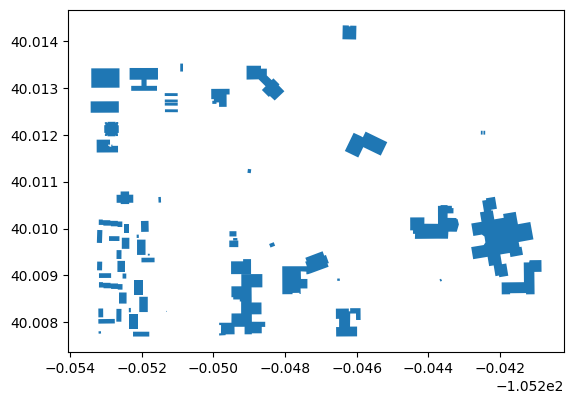

In [ ]:
# Plot the buildings
buildings.plot()

In [ ]:
# BONUS - Select the SEEC building from the buildings geodataframe
seec = buildings[buildings["name"] == "Sustainability, Energy and Environment Community"]
seec

,,geometry,addr:city,addr:housenumber,addr:state,addr:street,building,building:levels,building:levels:underground,building:material,description,...,shelter_type,building:colour,height,man_made,roof:shape,telescope:type,website,wikipedia,faculty,start_date
element,id,,,,,,,,,,,,,,,,,,,,,
way,99613171,"POLYGON ((-105.24256 40.01035, -105.24245 40.0...",Boulder,4001,CO,Discovery Drive,university,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# BONUS - Select the SEEC building from the buildings geodataframe (again)
seec = buildings[buildings["addr:housenumber"] == "4001"]
seec

,,geometry,addr:city,addr:housenumber,addr:state,addr:street,building,building:levels,building:levels:underground,building:material,description,...,shelter_type,building:colour,height,man_made,roof:shape,telescope:type,website,wikipedia,faculty,start_date
element,id,,,,,,,,,,,,,,,,,,,,,
way,99613171,"POLYGON ((-105.24256 40.01035, -105.24245 40.0...",Boulder,4001,CO,Discovery Drive,university,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

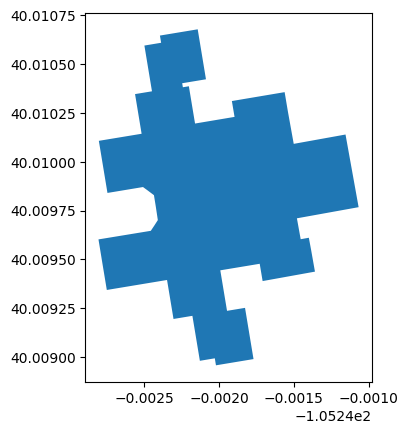

In [ ]:
# Plot SEEC
seec.plot()

## Find Roads Within the East Campus Boundary

Next, we will use the same East Campus polygon to search for roads and paths within the study area.

In OpenStreetMap, roads, streets, sidewalks, paths, and other travel routes are commonly stored using the `highway` tag. Even though the word “highway” may sound like it only refers to major roads, in OSM it is used more broadly to describe many types of transportation features.

The tag:

`{"highway": True}`

asks OpenStreetMap to return any feature inside the East Campus polygon that has a `highway` tag.

The result is stored as a GeoDataFrame called `roads`. Depending on what is available in OSM, this layer may include streets, service roads, bike paths, footpaths, sidewalks, or other transportation features.

Adding roads to the map will help provide context and make it easier to understand how buildings and other features are arranged across East Campus.

In [ ]:
# Get roads
roads = osm.features_from_polygon(polygon,
                                      tags={"highway": True})
roads

geometry  \
element id                                                              
node    25758250                          POINT (-105.24844 40.00762)   
        176528633                         POINT (-105.24722 40.01362)   
        2043601882                        POINT (-105.24571 40.00749)   
        2043601898                        POINT (-105.24834 40.00762)   
        2043601902                        POINT (-105.24343 40.00761)   
...                                                               ...   
way     1504631065  LINESTRING (-105.25365 40.01284, -105.25365 40...   
        1504631066  LINESTRING (-105.25339 40.01091, -105.2534 40....   
        1504631067  LINESTRING (-105.25339 40.01085, -105.25339 40...   
        1504631073  LINESTRING (-105.25364 40.01356, -105.25364 40...   
        1506465255  LINESTRING (-105.25065 40.00722, -105.25065 40...   

                     highway bicycle      crossing source crossing:markings  \
element id                                                                    
node    25758250    crossing     NaN           NaN    NaN               NaN   
        176528633   crossing     NaN  uncontrolled   Bing               NaN   
        2043601882  crossing     NaN           NaN    NaN               NaN   
        2043601898  crossing     NaN           NaN    NaN               NaN   
        2043601902  crossing     NaN           NaN    NaN               NaN   
...                      ...     ...           ...    ...               ...   
way     1504631065  cycleway     NaN  uncontrolled    NaN             zebra   
        1504631066   footway     NaN           NaN    NaN               NaN   
        1504631067   footway     NaN  uncontrolled    NaN             zebra   
        1504631073  cycleway     NaN         zebra    NaN             zebra   
        1506465255   footway     NaN        marked    NaN             zebra   

                   flashing_lights crossing:signals  bus name  ...  cycleway  \
element id                                                     ...             
node    25758250               NaN              NaN  NaN  NaN  ...       NaN   
        176528633              NaN              NaN  NaN  NaN  ...       NaN   
        2043601882             NaN              NaN  NaN  NaN  ...       NaN   
        2043601898             NaN              NaN  NaN  NaN  ...       NaN   
        2043601902             NaN              NaN  NaN  NaN  ...       NaN   
...                            ...              ...  ...  ...  ...       ...   
way     1504631065             NaN               no  NaN  NaN  ...  crossing   
        1504631066             NaN              NaN  NaN  NaN  ...       NaN   
        1504631067             NaN               no  NaN  NaN  ...       NaN   
        1504631073             NaN              NaN  NaN  NaN  ...  crossing   
        1506465255          button              NaN  NaN  NaN  ...       NaN   

                   button_operated access step_count mapillary maxweight  \
element id                                                                 
node    25758250               NaN    NaN        NaN       NaN       NaN   
        176528633              NaN    NaN        NaN       NaN       NaN   
        2043601882             NaN    NaN        NaN       NaN       NaN   
        2043601898             NaN    NaN        NaN       NaN       NaN   
        2043601902             NaN    NaN        NaN       NaN       NaN   
...                            ...    ...        ...       ...       ...   
way     1504631065             NaN    NaN        NaN       NaN       NaN   
        1504631066             NaN    NaN        NaN       NaN       NaN   
        1504631067             NaN    NaN        NaN       NaN       NaN   
        1504631073             NaN    NaN        NaN       NaN       NaN   
        1506465255             NaN    NaN        NaN       NaN       NaN   

                   informal handrail path crossing:is

## Plot Roads and the Campus Boundary Together

Before adding more layers, it is useful to make a quick plot to check how our data line up.

In this step, we plot the **roads** layer and the **East Campus boundary** on the same map. This helps us see whether the roads returned from OpenStreetMap fall within the study area and whether the boundary looks reasonable.

This is an important part of working with spatial data. As we add and modify layers, we will repeatedly make quick plots to check our work. These checks help us catch problems early, such as missing data, unexpected geometries, or features that extend beyond our area of interest.

The East Campus boundary is plotted with no fill color and a black outline so that we can see the roads underneath it.

<Axes: >

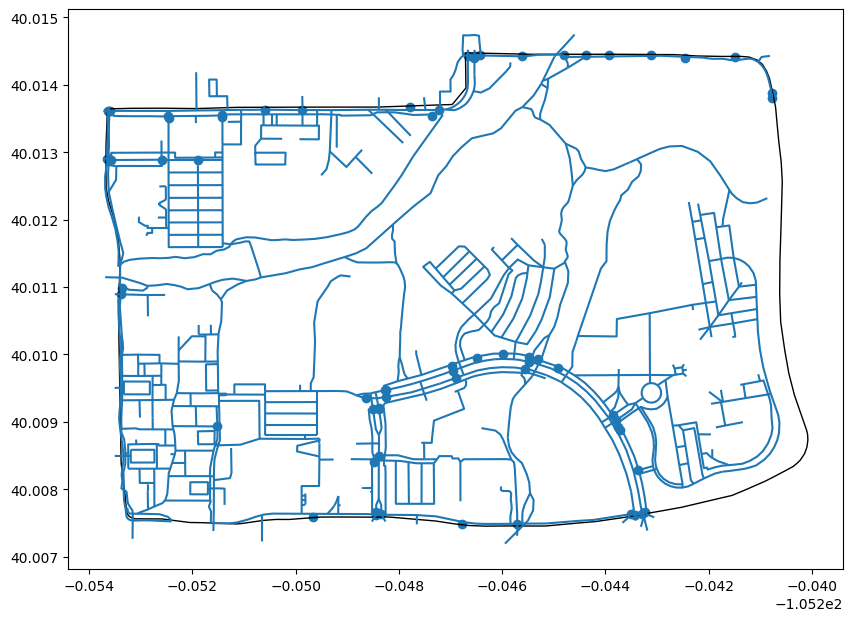

In [ ]:
# Plot roads and boundary together
fig, ax = plt.subplots(figsize=(10,10))
roads.plot(ax=ax)
east_campus.plot(ax=ax, color='None', edgecolor='black')

## Clip Roads to the Campus Boundary

When we plotted the roads and East Campus boundary together, we noticed that some road features extended beyond the campus boundary.

This happens because OpenStreetMap features are not always neatly divided at the edge of our study area. A road may pass through East Campus but continue beyond the boundary, so OSM returns the full road segment rather than only the portion inside the campus.

To focus our map on East Campus, we can **clip** the roads layer to the campus boundary.

Clipping is a common spatial operation that trims one layer using the shape of another layer. In this case, we are using the East Campus boundary as a “cookie cutter” to keep only the parts of the roads that fall inside the boundary.

The result is a new GeoDataFrame called `roads_clipped`, which contains only the road features within East Campus.

In [ ]:
# Clip roads to campus boundary
roads_clipped = gpd.clip(
    roads,
    east_campus
)

roads_clipped

geometry  \
element id                                                              
way     1506465255  LINESTRING (-105.25065 40.00753, -105.25065 40...   
        193852611   LINESTRING (-105.25151 40.00749, -105.25128 40...   
node    4719876590                        POINT (-105.24966 40.00759)   
way     490397300   LINESTRING (-105.24918 40.00763, -105.24917 40...   
        490397303   LINESTRING (-105.24938 40.00763, -105.2493 40....   
...                                                               ...   
        1476034556  LINESTRING (-105.25362 40.01364, -105.25362 40...   
        647528674   LINESTRING (-105.25106 40.01363, -105.25132 40...   
node    2135433594                        POINT (-105.25059 40.01363)   
way     577440220   LINESTRING (-105.25132 40.01362, -105.25132 40...   
        207270745   LINESTRING (-105.25192 40.01365, -105.25192 40...   

                     highway     bicycle      crossing  \
element id                                               
way     1506465255   footway         NaN        marked   
        193852611   cycleway  designated           NaN   
node    4719876590  bus_stop         NaN           NaN   
way     490397300      steps         NaN           NaN   
        490397303      steps         NaN           NaN   
...                      ...         ...           ...   
        1476034556   footway         NaN  uncontrolled   
        647528674   tertiary         NaN           NaN   
node    2135433594  crossing         NaN           NaN   
way     577440220    service         NaN           NaN   
        207270745    service         NaN           NaN   

                                                               source  \
element id                                                              
way     1506465255                                                NaN   
        193852611                                                 NaN   
node    4719876590  RTD Denver, https://transitfeeds.com/p/rtd-den...   
way     490397300                                                 NaN   
        490397303                                                 NaN   
...                                                               ...   
        1476034556                                                NaN   
        647528674                                                 NaN   
node    2135433594                                                NaN   
way     577440220                                                 NaN   
        207270745                                                 NaN   

                   crossing:markings flashing_lights crossing:signals  bus  \
element id                                                                   
way     1506465255             zebra          button              NaN  NaN   
        193852611                NaN             NaN              NaN  NaN   
node    4719876590               NaN             NaN              NaN  yes   
way     490397300                NaN             NaN              NaN  NaN   
        490397303                NaN             NaN              NaN  NaN   
...                              ...             ...              ...  ...   
        1476034556             zebra             NaN               no  NaN   
        647528674                NaN             NaN              NaN  NaN   
node    2135433594               NaN             NaN              NaN  NaN   
way     577440220                NaN             NaN              NaN  NaN   
        207270745                NaN             NaN              NaN  NaN   

                                          name  ... cycleway button_operated  \
element id                                      ...                            
way     1506465255                         NaN  ...      NaN             NaN   
        193852611   Colorado Avenue North Path  ...      NaN             NaN   
node    4719876590      Colorado Ave & 33rd St  ...      NaN           

## Check the Clipped Roads Layer

After clipping the roads to the East Campus boundary, we should plot the data again to check the result.

This map shows the **clipped roads** and the **East Campus boundary** together. The goal is to confirm that the roads now stay within the campus boundary instead of extending beyond it.

This kind of visual check is an important part of spatial data wrangling. Each time we modify a layer, we want to quickly inspect the output before moving on. This helps us make sure the data are behaving the way we expect.

If the clipping worked correctly, the road features should now be limited to the area inside the East Campus boundary.

<Axes: >

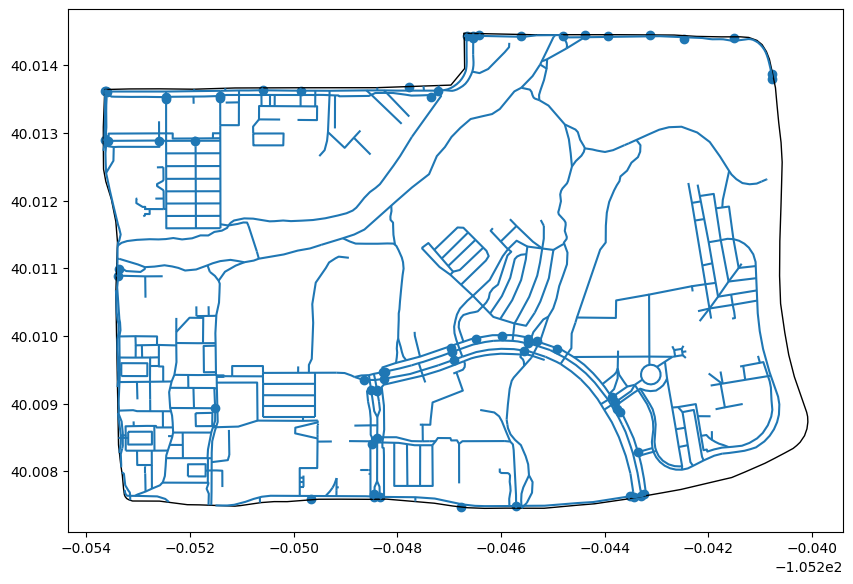

In [ ]:
# Plot clipped roads and boundary together
fig, ax = plt.subplots(figsize=(10,10))
roads_clipped.plot(ax=ax)
east_campus.plot(ax=ax, color='None', edgecolor='black')

## Keep Only Road Line Features

Later in the notebook, we will create an **interactive map** with multiple layers. For interactive plotting, each layer works best when it contains only one type of geometry.

The clipped roads layer may include more than one geometry type. For example, it may contain:

- **LineString** features, which represent individual road or path lines
- **MultiLineString** features, which represent road or path features made up of multiple connected line segments
- **Point** features, sometimes called nodes, which represent individual locations

Because roads are best represented as lines on a map, we will create a new GeoDataFrame that keeps only the `LineString` and `MultiLineString` geometries.

The result is saved as `road_lines`. This cleaned-up layer will be easier to use when we build the final interactive map.

In [ ]:
# Keep only linestring for interactive plotting
road_lines = roads_clipped[
    roads_clipped.geometry.type.isin(["LineString", "MultiLineString"])]
road_lines

geometry  \
element id                                                              
way     1506465255  LINESTRING (-105.25065 40.00753, -105.25065 40...   
        193852611   LINESTRING (-105.25151 40.00749, -105.25128 40...   
        490397300   LINESTRING (-105.24918 40.00763, -105.24917 40...   
        490397303   LINESTRING (-105.24938 40.00763, -105.2493 40....   
        490397295   LINESTRING (-105.24988 40.00777, -105.24981 40...   
...                                                               ...   
        1504631073  LINESTRING (-105.25364 40.01356, -105.25364 40...   
        1476034556  LINESTRING (-105.25362 40.01364, -105.25362 40...   
        647528674   LINESTRING (-105.25106 40.01363, -105.25132 40...   
        577440220   LINESTRING (-105.25132 40.01362, -105.25132 40...   
        207270745   LINESTRING (-105.25192 40.01365, -105.25192 40...   

                     highway     bicycle      crossing source  \
element id                                                      
way     1506465255   footway         NaN        marked    NaN   
        193852611   cycleway  designated           NaN    NaN   
        490397300      steps         NaN           NaN    NaN   
        490397303      steps         NaN           NaN    NaN   
        490397295      steps         NaN           NaN    NaN   
...                      ...         ...           ...    ...   
        1504631073  cycleway         NaN         zebra    NaN   
        1476034556   footway         NaN  uncontrolled    NaN   
        647528674   tertiary         NaN           NaN    NaN   
        577440220    service         NaN           NaN    NaN   
        207270745    service         NaN           NaN    NaN   

                   crossing:markings flashing_lights crossing:signals  bus  \
element id                                                                   
way     1506465255             zebra          button              NaN  NaN   
        193852611                NaN             NaN              NaN  NaN   
        490397300                NaN             NaN              NaN  NaN   
        490397303                NaN             NaN              NaN  NaN   
        490397295                NaN             NaN              NaN  NaN   
...                              ...             ...              ...  ...   
        1504631073             zebra             NaN              NaN  NaN   
        1476034556             zebra             NaN               no  NaN   
        647528674                NaN             NaN              NaN  NaN   
        577440220                NaN             NaN              NaN  NaN   
        207270745                NaN             NaN              NaN  NaN   

                                          name  ...  cycleway button_operated  \
element id                                      ...                             
way     1506465255                         NaN  ...       NaN             NaN   
        193852611   Colorado Avenue North Path  ...       NaN             NaN   
        490397300                          NaN  ...       NaN             NaN   
        490397303                          NaN  ...       NaN             NaN   
        490397295                          NaN  ...       NaN             NaN   
...                                        ...  ...       ...             ...   
        1504631073                         NaN  ...  crossing             NaN   
        1476034556                         NaN  ...       NaN             NaN   
        647528674                Marine Street  ...       NaN             NaN   
        577440220                          NaN  ...       NaN             NaN   
        207270745                          NaN  ...       NaN             NaN   

                   access step_count mapillary maxweight informal handrail  \
element id                                                                   
way     1506465255    NaN        NaN    

## Find Water Features Within the East Campus Boundary

Next, we will repeat the same general workflow we used for roads, but this time we will search for **water features** within the East Campus boundary.

OpenStreetMap stores water-related features using several different tags. In this example, we search for features that may be labeled as natural water, waterways, or other water features.

These tags can return features such as ponds, streams, drainage channels, ditches, or other mapped water-related areas, depending on what is available in OSM for the study area.

The result is stored as a GeoDataFrame called `water`. Each row represents a water-related feature returned from OpenStreetMap, and the `geometry` column stores its spatial shape.

Adding water features will make our campus map more complete and help show how built infrastructure, roads, and natural or semi-natural features fit together across East Campus.

In [ ]:
# Get water
water = osm.features_from_polygon(polygon,
                                      tags={"natural":"water",
                                            "waterway": True,
                                            "water":True})
water

geometry  \
element id                                                             
way     61758946   LINESTRING (-105.29443 40.01364, -105.29417 40...   
        119868815  POLYGON ((-105.24151 40.01308, -105.24154 40.0...   
        119868816  POLYGON ((-105.24468 40.01346, -105.24472 40.0...   
        119868817  POLYGON ((-105.24297 40.01378, -105.24303 40.0...   
        119868818  POLYGON ((-105.24561 40.01325, -105.24554 40.0...   
        121868783  POLYGON ((-105.24708 40.00863, -105.24706 40.0...   
        121868784  POLYGON ((-105.24559 40.00902, -105.24562 40.0...   
        203311102  LINESTRING (-105.24545 40.00957, -105.24511 40...   
        203311103  LINESTRING (-105.24349 40.0137, -105.24346 40....   
        203311104  LINESTRING (-105.24204 40.01336, -105.24189 40...   
        203311158  LINESTRING (-105.24097 40.01238, -105.24087 40...   
        203314483  LINESTRING (-105.24514 40.01322, -105.24498 40...   
        362866018  LINESTRING (-105.24068 40.01219, -105.24014 40...   
        471298469  LINESTRING (-105.24568 40.00876, -105.24593 40...   
        471298470  LINESTRING (-105.24707 40.00862, -105.24731 40...   
        672533372  LINESTRING (-105.24498 40.01327, -105.24492 40...   
        672533373  LINESTRING (-105.24492 40.0133, -105.24473 40....   
        672533374  LINESTRING (-105.24544 40.00753, -105.24532 40...   
        672533375  LINESTRING (-105.24585 40.00719, -105.24544 40...   
        762585114  LINESTRING (-105.24601 40.00872, -105.24604 40...   
        762585115  LINESTRING (-105.24593 40.00873, -105.24601 40...   
        977341022  POLYGON ((-105.24858 40.01116, -105.24862 40.0...   

                  intermittent            name waterway natural water layer  \
element id                                                                    
way     61758946            no   Boulder Creek   stream     NaN   NaN   NaN   
        119868815          NaN             NaN      NaN   water   NaN   NaN   
        119868816          NaN             NaN      NaN   water   NaN   NaN   
        119868817          NaN             NaN      NaN   water   NaN   NaN   
        119868818          NaN  The Honey Hole      NaN   water   NaN   NaN   
        121868783          NaN             NaN      NaN   water  pond   NaN   
        121868784          NaN             NaN      NaN   water   NaN   NaN   
        203311102          NaN     Skunk Creek   stream     NaN   NaN   NaN   
        203311103          NaN             NaN   stream     NaN   NaN   NaN   
        203311104          NaN             NaN   stream     NaN   NaN   NaN   
        203311158          NaN             NaN   stream     NaN   NaN   NaN   
        203314483          NaN             NaN   stream     NaN   NaN   NaN   
        362866018          NaN             NaN   stream     NaN   NaN    -1   
        471298469          NaN             NaN    canal     NaN   NaN   NaN   
        471298470          NaN             NaN    canal     NaN   NaN   NaN   
        672533372          NaN             NaN   stream     NaN   NaN    -1   
        672533373          NaN             NaN   stream     NaN   NaN   NaN   
        672533374          NaN     Skunk Creek   stream     NaN   NaN   NaN   
        672533375          NaN     Skunk Creek   stream     NaN   NaN    -1   
        762585114          NaN             NaN    canal     NaN   NaN   NaN   
        762585115          NaN             NaN    canal     NaN   NaN    -1   
        977341022          NaN             NaN      NaN   water   NaN   NaN   

                    tunnel area     athletics leisure      sport  
element id                                                        
way     61758946       NaN  NaN           NaN     NaN        NaN  
        119868815      NaN  NaN           NaN     NaN        NaN  
        119868816      NaN  NaN           NaN     NaN        NaN  
        119868817      NaN  NaN           NaN     NaN        NaN  
        119868818      NaN  NaN 

## Plot Water Features and the Campus Boundary

After downloading the water features, we will plot them with the East Campus boundary to check how the layer looks.

This quick plot helps us see whether the water features returned from OpenStreetMap are located within or near the East Campus study area. As with the roads layer, some features may extend beyond the boundary depending on how they are stored in OSM.

This visual check helps us decide whether the water layer needs additional cleaning, such as clipping to the campus boundary or filtering by geometry type.

The East Campus boundary is plotted with no fill color and a black outline so that we can see how the water features line up with the study area.

<Axes: >

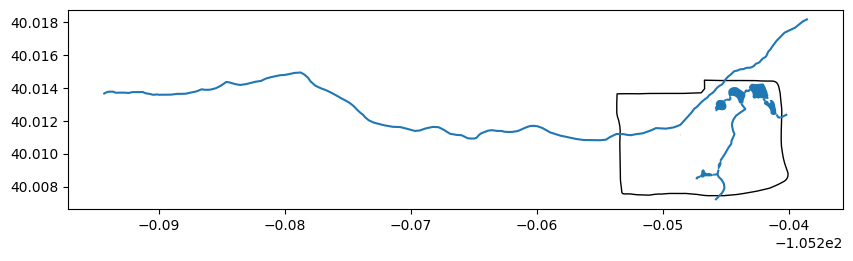

In [ ]:
# Plot water and boundary together
fig, ax = plt.subplots(figsize=(10,10))
water.plot(ax=ax)
east_campus.plot(ax=ax, color='None', edgecolor='black')

## Clip Water Features to the Campus Boundary

Just like we did with the roads layer, we can clip the water features to the East Campus boundary.

Some water features may extend beyond our study area because OpenStreetMap stores them as larger connected features. For example, a stream, drainage channel, or pond edge may continue outside the campus boundary even if only part of it passes through East Campus.

Clipping trims the water layer so that only the portions inside the East Campus boundary are kept.

The result is saved as `water_clipped`. This cleaned-up layer will help keep the final map focused on the East Campus study area.

In [ ]:
# Clip water lines to campus boundary
water_clipped = gpd.clip(
    water,
    east_campus
)

water_clipped


geometry  \
element id                                                             
way     672533375  LINESTRING (-105.24553 40.00745, -105.24544 40...   
        672533374  LINESTRING (-105.24544 40.00753, -105.24532 40...   
        471298470  LINESTRING (-105.24707 40.00862, -105.24731 40...   
        762585114  LINESTRING (-105.24601 40.00872, -105.24604 40...   
        762585115  LINESTRING (-105.24593 40.00873, -105.24601 40...   
        471298469  LINESTRING (-105.24568 40.00876, -105.24593 40...   
        121868783  POLYGON ((-105.24706 40.00869, -105.24701 40.0...   
        121868784  POLYGON ((-105.24562 40.00904, -105.24565 40.0...   
        977341022  POLYGON ((-105.24858 40.01113, -105.24862 40.0...   
        119868818  POLYGON ((-105.24554 40.01327, -105.24547 40.0...   
        203311102  LINESTRING (-105.24545 40.00957, -105.24511 40...   
        203311158  LINESTRING (-105.24097 40.01238, -105.24087 40...   
        362866018  LINESTRING (-105.24068 40.01219, -105.24058 40...   
        119868815  POLYGON ((-105.24149 40.01311, -105.24148 40.0...   
        203314483  LINESTRING (-105.24514 40.01322, -105.24498 40...   
        203311104  LINESTRING (-105.24204 40.01336, -105.24189 40...   
        672533372  LINESTRING (-105.24498 40.01327, -105.24492 40...   
        672533373  LINESTRING (-105.24492 40.0133, -105.24473 40....   
        119868816  POLYGON ((-105.24472 40.01346, -105.24475 40.0...   
        119868817  POLYGON ((-105.24303 40.01382, -105.24308 40.0...   
        203311103  LINESTRING (-105.24349 40.0137, -105.24346 40....   
        61758946   LINESTRING (-105.25341 40.0112, -105.25317 40....   

                  intermittent            name waterway natural water layer  \
element id                                                                    
way     672533375          NaN     Skunk Creek   stream     NaN   NaN    -1   
        672533374          NaN     Skunk Creek   stream     NaN   NaN   NaN   
        471298470          NaN             NaN    canal     NaN   NaN   NaN   
        762585114          NaN             NaN    canal     NaN   NaN   NaN   
        762585115          NaN             NaN    canal     NaN   NaN    -1   
        471298469          NaN             NaN    canal     NaN   NaN   NaN   
        121868783          NaN             NaN      NaN   water  pond   NaN   
        121868784          NaN             NaN      NaN   water   NaN   NaN   
        977341022          NaN             NaN      NaN   water   NaN   NaN   
        119868818          NaN  The Honey Hole      NaN   water   NaN   NaN   
        203311102          NaN     Skunk Creek   stream     NaN   NaN   NaN   
        203311158          NaN             NaN   stream     NaN   NaN   NaN   
        362866018          NaN             NaN   stream     NaN   NaN    -1   
        119868815          NaN             NaN      NaN   water   NaN   NaN   
        203314483          NaN             NaN   stream     NaN   NaN   NaN   
        203311104          NaN             NaN   stream     NaN   NaN   NaN   
        672533372          NaN             NaN   stream     NaN   NaN    -1   
        672533373          NaN             NaN   stream     NaN   NaN   NaN   
        119868816          NaN             NaN      NaN   water   NaN   NaN   
        119868817          NaN             NaN      NaN   water   NaN   NaN   
        203311103          NaN             NaN   stream     NaN   NaN   NaN   
        61758946            no   Boulder Creek   stream     NaN   NaN   NaN   

                    tunnel area     athletics leisure      sport  
element id                                                        
way     672533375  culvert  NaN           NaN     NaN        NaN  
        672533374      NaN  NaN           NaN     NaN        NaN  
        471298470      NaN  NaN           NaN     NaN        NaN  
        762585114      NaN  NaN           NaN     NaN        NaN  
        762585115  culvert  NaN 

<Axes: >

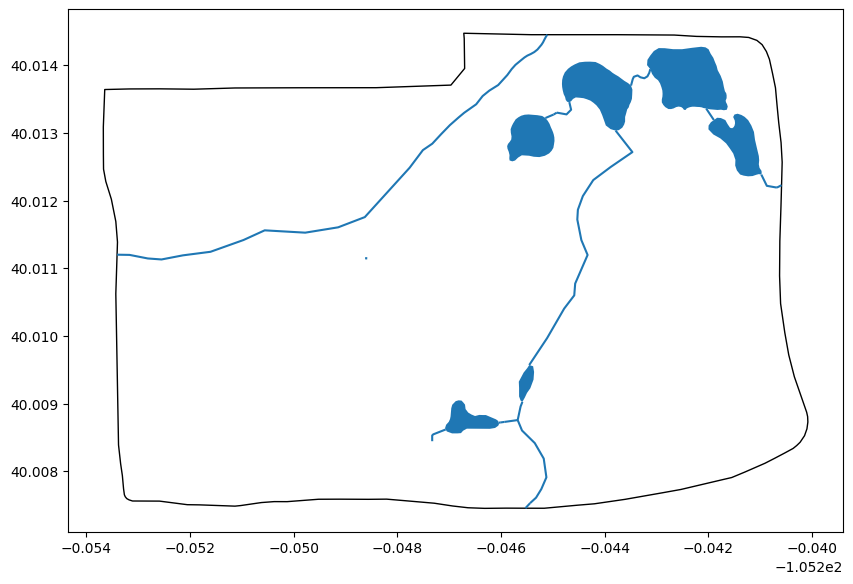

In [ ]:
# Plot water and boundary together
fig, ax = plt.subplots(figsize=(10,10))
water_clipped.plot(ax=ax)
east_campus.plot(ax=ax, color='None', edgecolor='black')

## Separate Water Features by Geometry Type

Before making the final interactive map, we will separate the clipped water features by geometry type.

Water features in OpenStreetMap can be represented in different ways. For example:

- **Polygon** or **MultiPolygon** features may represent areas of water, such as ponds, lakes, or reservoirs.
- **LineString** or **MultiLineString** features may represent linear water features, such as streams, ditches, or drainage channels.

Interactive maps often work best when each layer contains only one type of geometry. To make plotting easier, we will create two separate GeoDataFrames:

- `water_polygons` for area-based water features
- `water_lines` for line-based water features

This gives us more control over how each type of water feature appears on the final map.

In [ ]:
# Splitting water into lines and polygons for easier plotting
water_polygons = water_clipped[
    water_clipped.geometry.geom_type.isin(
        ["Polygon", "MultiPolygon"])]

water_polygons


water_lines = water_clipped[
    water_clipped.geometry.geom_type.isin(
        ["LineString", "MultiLineString"])]

water_lines


geometry  \
element id                                                             
way     672533375  LINESTRING (-105.24553 40.00745, -105.24544 40...   
        672533374  LINESTRING (-105.24544 40.00753, -105.24532 40...   
        471298470  LINESTRING (-105.24707 40.00862, -105.24731 40...   
        762585114  LINESTRING (-105.24601 40.00872, -105.24604 40...   
        762585115  LINESTRING (-105.24593 40.00873, -105.24601 40...   
        471298469  LINESTRING (-105.24568 40.00876, -105.24593 40...   
        203311102  LINESTRING (-105.24545 40.00957, -105.24511 40...   
        203311158  LINESTRING (-105.24097 40.01238, -105.24087 40...   
        362866018  LINESTRING (-105.24068 40.01219, -105.24058 40...   
        203314483  LINESTRING (-105.24514 40.01322, -105.24498 40...   
        203311104  LINESTRING (-105.24204 40.01336, -105.24189 40...   
        672533372  LINESTRING (-105.24498 40.01327, -105.24492 40...   
        672533373  LINESTRING (-105.24492 40.0133, -105.24473 40....   
        203311103  LINESTRING (-105.24349 40.0137, -105.24346 40....   
        61758946   LINESTRING (-105.25341 40.0112, -105.25317 40....   

                  intermittent           name waterway natural water layer  \
element id                                                                   
way     672533375          NaN    Skunk Creek   stream     NaN   NaN    -1   
        672533374          NaN    Skunk Creek   stream     NaN   NaN   NaN   
        471298470          NaN            NaN    canal     NaN   NaN   NaN   
        762585114          NaN            NaN    canal     NaN   NaN   NaN   
        762585115          NaN            NaN    canal     NaN   NaN    -1   
        471298469          NaN            NaN    canal     NaN   NaN   NaN   
        203311102          NaN    Skunk Creek   stream     NaN   NaN   NaN   
        203311158          NaN            NaN   stream     NaN   NaN   NaN   
        362866018          NaN            NaN   stream     NaN   NaN    -1   
        203314483          NaN            NaN   stream     NaN   NaN   NaN   
        203311104          NaN            NaN   stream     NaN   NaN   NaN   
        672533372          NaN            NaN   stream     NaN   NaN    -1   
        672533373          NaN            NaN   stream     NaN   NaN   NaN   
        203311103          NaN            NaN   stream     NaN   NaN   NaN   
        61758946            no  Boulder Creek   stream     NaN   NaN   NaN   

                    tunnel area athletics leisure sport  
element id                                               
way     672533375  culvert  NaN       NaN     NaN   NaN  
        672533374      NaN  NaN       NaN     NaN   NaN  
        471298470      NaN  NaN       NaN     NaN   NaN  
        762585114      NaN  NaN       NaN     NaN   NaN  
        762585115  culvert  NaN       NaN     NaN   NaN  
        471298469      NaN  NaN       NaN     NaN   NaN  
        203311102      NaN  NaN       NaN     NaN   NaN  
        203311158      NaN  NaN       NaN     NaN   NaN  
        362866018      yes  NaN       NaN     NaN   NaN  
        203314483      NaN  NaN       NaN     NaN   NaN  
        203311104      NaN  NaN       NaN     NaN   NaN  
        672533372  culvert  NaN       NaN     NaN   NaN  
        672533373      NaN  NaN       NaN     NaN   NaN  
        203311103      NaN  NaN       NaN     NaN   NaN  
        61758946       NaN  NaN       NaN     NaN   NaN

## Create a Static Map with All Layers

Now that we have downloaded and cleaned several OpenStreetMap layers, we can plot them together on one map.

This static map includes:

- the **East Campus boundary**
- **buildings**
- **roads and paths**
- **water features**

Plotting all of the layers together allows us to see how the different features relate to one another across the campus. Buildings provide structure, roads and paths show movement through the area, and water features add environmental context.

This map is still a static image, but it is an important checkpoint before creating the final interactive version. It lets us confirm that the layers overlap correctly and that the map includes the main features we want to show.

The map title describes the place being mapped and identifies OpenStreetMap as the data source.

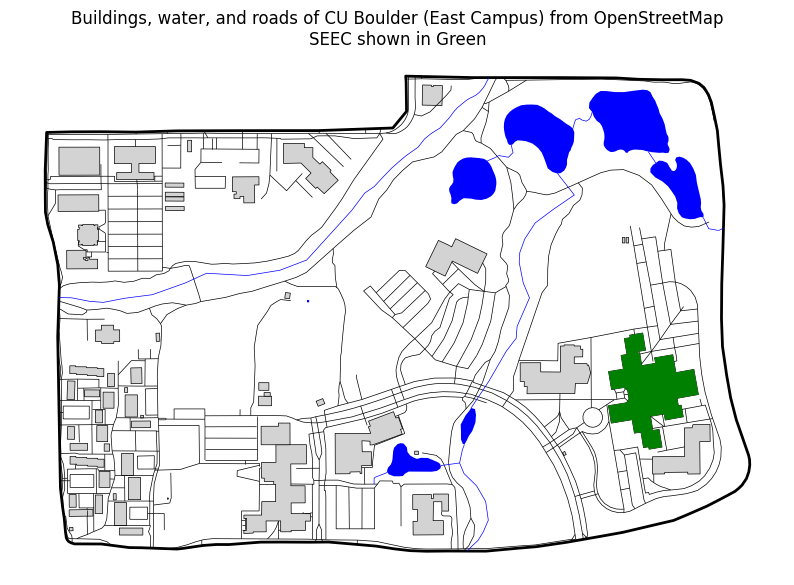

In [ ]:
# Plot all layers together on a single axis
fig, ax = plt.subplots(figsize=(10, 10))

# Plot East Campus boundary
east_campus.plot(
    ax=ax,
    color="None",
    linewidth=2
)

# Plot buildings
buildings.plot(
    ax=ax,
    color="lightgray",
    edgecolor="black",
    linewidth=0.5
)

# Plot roads
road_lines.plot(
    ax=ax,
    color="black",
    linewidth=0.5)

# Plot water
water_clipped.plot(
    ax=ax,
    color="blue",
    linewidth=0.5)

# Plot SEEC
seec.plot(ax=ax,
          color='green',
          label='SEEC')


ax.set_title("Buildings, water, and roads of CU Boulder (East Campus) from OpenStreetMap\nSEEC shown in Green")
ax.set_axis_off()

plt.show()

In [ ]:
# Create an interactive map using hvplot
buildings_map = buildings.hvplot(
    geo=True,
    tiles="OSM",
    fill_color="yellow",
    line_color="black",
    alpha=1.0,
    line_width=2,
    height=600,
    width=800,
    title="CU Boulder (East Campus)"
)

east_campus_map = east_campus.hvplot(
    geo=True,
    fill_color="yellow",
    line_color="black",
    fill_alpha=0.3,
    line_width=5
)

creek_map = water_lines.hvplot(
    geo=True,
    line_color="blue",
    line_width=4
)

pond_map = water_polygons.hvplot(
    geo=True,
    line_color="blue",
    fill_color="blue",
    fill_alpha=0.3,
    line_width=2
)

road_map = road_lines.hvplot(
    geo=True,
    line_color="black",
    line_width=1,
    alpha=0.8
)

seec_map = seec.hvplot(
    geo=True,
    line_color="black",
    fill_color='red',
    line_width=1
)



east_campus_map = buildings_map * east_campus_map * creek_map * pond_map * road_map * seec_map

# Save the map as a file to put on the web (OPTIONAL)
hv.save(east_campus_map, 'east_campus_map.html')

east_campus_map

:Overlay
   .WMTS.I       :WMTS   [Longitude,Latitude]
   .Polygons.I   :Polygons   [Longitude,Latitude]
   .Polygons.II  :Polygons   [Longitude,Latitude]
   .Path.I       :Path   [Longitude,Latitude]
   .Polygons.III :Polygons   [Longitude,Latitude]
   .Path.II      :Path   [Longitude,Latitude]
   .Polygons.IV  :Polygons   [Longitude,Latitude]